## Random Forest for Regression


In this exercise, we'll use a **Random Forest Regressor** to solve a polynomial regression task.  We'll investigate the model's capability to both interpolate and extrapolate through varying the model parameters and training and test data.

First, we'll load in all of the required libraries before we create some toy data for both training and testing.

### 0. Import Required Libraries

In [7]:
import numpy as np
import sklearn as sk
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools

### 1. Generate Synthetic Data

The toy data we'll create for this problem will be a set 50 of x and y pairs, $D = \{x, y\}$, where $ x \in [-3.2, 3.2]$ and we have a function $ f:x \rightarrow y $.  Our function will be the following cubic polynomial:

$$
    y = 1.28 \cdot x^3 - 6.4 \cdot x + 1
$$.  

So create the dataset using numpy and then plot it to ensure that we have the cubic polynomial that we expect.

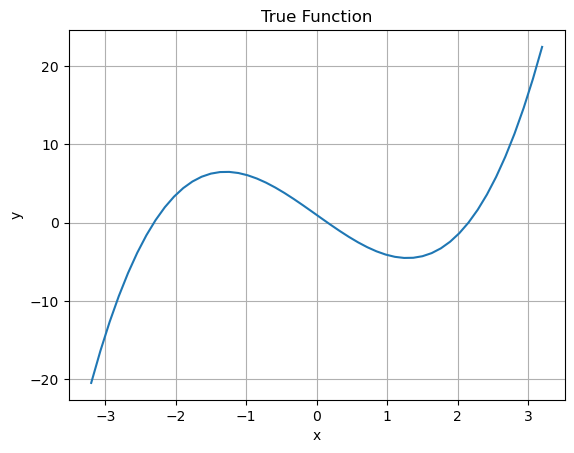

In [8]:
# Generate x values from -3.2 to 3.2
x = np.linspace(-3.2, 3.2, 50)

# Define cubic function for y
y = 1.28 * x**3 - 6.4 * x + 1

# Plot the original function
plt.plot(x, y)
plt.title('True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

### 2.(a) Train a Random Forest Regressor

We'll use the x and y data we've already created as training data but we need to generate some test data as well, so let's do that first for $ x \in [-2.56, 2.56]$, such that we're only testing the model's ability to interpolate at the moment.

Then, we'll fit a small random forest, where the trees are shallow; for example, try using 2 or 3 trees with a maximum depth of 2 or 3.

In [9]:
# Generate some test data, including observations from the true function
x_test = np.linspace(-2.56, 2.56, 100)
y_obs = 1.28 * x_test**3 - 6.4 * x_test + 1

# Instantiate and train the regressor
regressor = RandomForestRegressor(
    n_estimators= 3,
    max_depth= 2,
    oob_score=True  # Optional: enables out-of-bag scoring
)
regressor.fit(x.reshape(-1, 1), y)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:578: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


RandomForestRegressor(max_depth=2, n_estimators=3, oob_score=True)

### 2.(b) Predict on a Test Grid and Evaluate its Performance

The next step is to use the random forest to make y value predictions and compare them against the observations we generated above.  The metric we'll use here is $R^2$, calculated pairwise between an observation, $y$, and a prediction $y'$, as follows:

$$
R^2 = 1 - \frac{\Sigma_{i=1}^n(y_i-y_i')^2}{\Sigma_{i=1}^n(y_i-\bar{y})^2}
$$

Luckily we don't need to code that as we've imported a function that calculates $R^2$ from arrays of predictions and observations (provided they are both arranged pairwise) from scikit-learn.  We'll also create an initial plot, showing our predicted function and the original, observed one.

0.022943931453714428


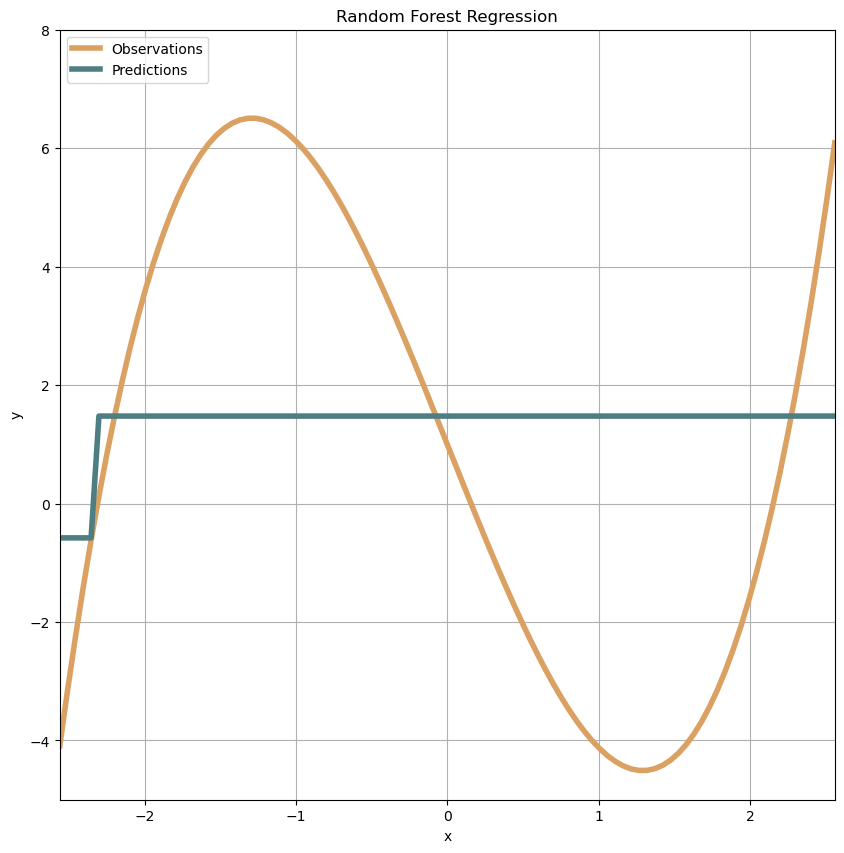

In [10]:
# Create test points and predict
y_pred = regressor.predict(x_test.reshape(-1, 1))
print(r2_score(y_obs, y_pred))

# Plot predictions and observations
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([-2.56, 2.56])
ax.set_ylim([-5, 8])
ax.plot(x_test, y_obs, lw=4, color='#dba162', label='Observations')
ax.plot(x_test, y_pred, lw=4, color='#4e7e82', label='Predictions')
plt.legend(loc="upper left")
plt.title("Random Forest Regression")
plt.grid(True)
plt.show()

### 2.(c) Increase The Number of Trees and Tree Size

The first random forest we trained wasn't particularly accurate.  What we'll do next is increase the number of trees and the amount of branching within each tree to investigate the effect on prediction performance through a systematic approach.  So we'll write a nested for loop for different pairs of random forest tree population size and maximum tree depth using itertools to plot them all at the same time.

R² Score for 2 Trees with Depth 2 = 0.015408871319775974
R² Score for 2 Trees with Depth 4 = 0.8383404800796279
R² Score for 2 Trees with Depth 8 = 0.9801916159199365
R² Score for 4 Trees with Depth 2 = 0.038812196821439215
R² Score for 4 Trees with Depth 4 = 0.8853047598946796
R² Score for 4 Trees with Depth 8 = 0.9899013836418452
R² Score for 8 Trees with Depth 2 = 0.15830780492733765
R² Score for 8 Trees with Depth 4 = 0.8855614755702454
R² Score for 8 Trees with Depth 8 = 0.9930559380494626


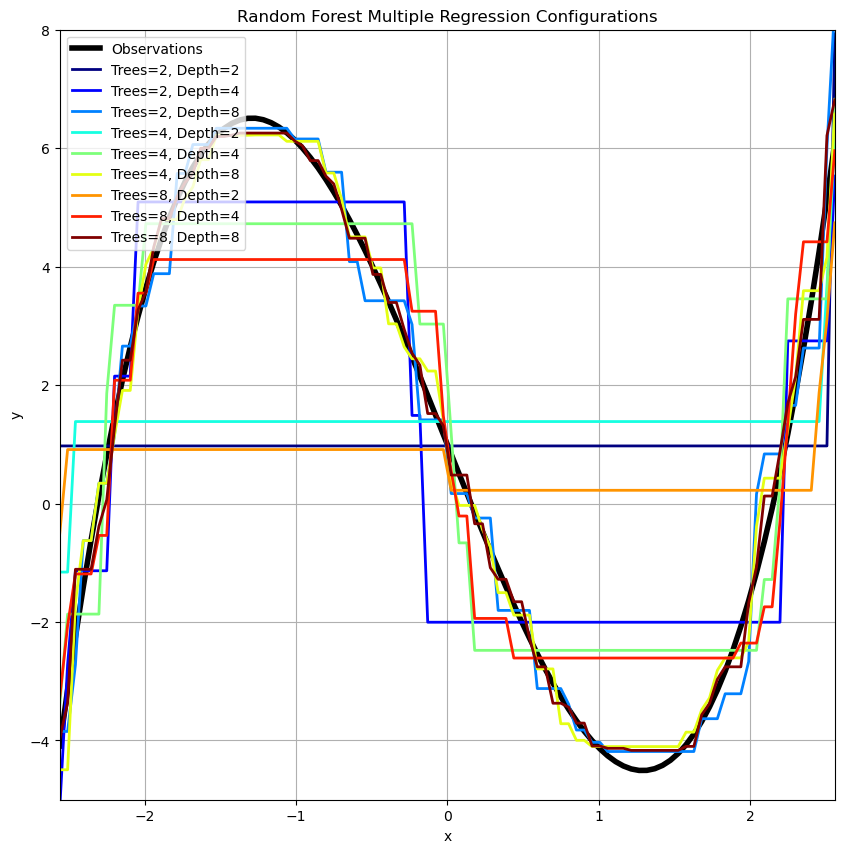

In [11]:
tree_counts = [2, 4, 8]
depth_counts = [2, 4, 8]
n_lines = len(tree_counts) * len(depth_counts)
cmap = mpl.colormaps['jet']
colours = cmap(np.linspace(0, 1, n_lines))

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([-2.56, 2.56])
ax.set_ylim([-5, 8])
ax.plot(x_test, y_obs, lw=4, color='black', label='Observations')

for i, (t, d) in enumerate(itertools.product(tree_counts, depth_counts)):
    regressor = RandomForestRegressor(n_estimators=t,
                                      max_depth=d)
    regressor.fit(x.reshape(-1, 1), y)
    y_pred = regressor.predict(x_test.reshape(-1, 1))
    print(f"R\u00b2 Score for {t} Trees with Depth {d} = {r2_score(y_obs, y_pred)}")
    label = f"Trees={t}, Depth={d}"
    ax.plot(x_test, y_pred, lw=2, color=colours[i], label=label)

plt.legend(loc="upper left")
plt.title("Random Forest Multiple Regression Configurations")
plt.grid(True)
plt.show()

### 3. Extrapolation with Random Forests

We've seen how random forests are capable of generating accurate results for regression tasks with a suitable depth and forest population, which partly depends on the complexity of the regression task.  The problem we have explored so far is one where the extremes we expect to encounter and predict were covered by the training data.  However, we will now investigate their capability to extrapolate beyond the limits of the training data.

We'll do this by using the problem as before but we'll change the range of the test set data to $ x \in [-5.12, 5.12]$.  We'll use a suitably sized random forest with a high maximum depth and generate predictions before plotting them as before.

0.38123299292234814


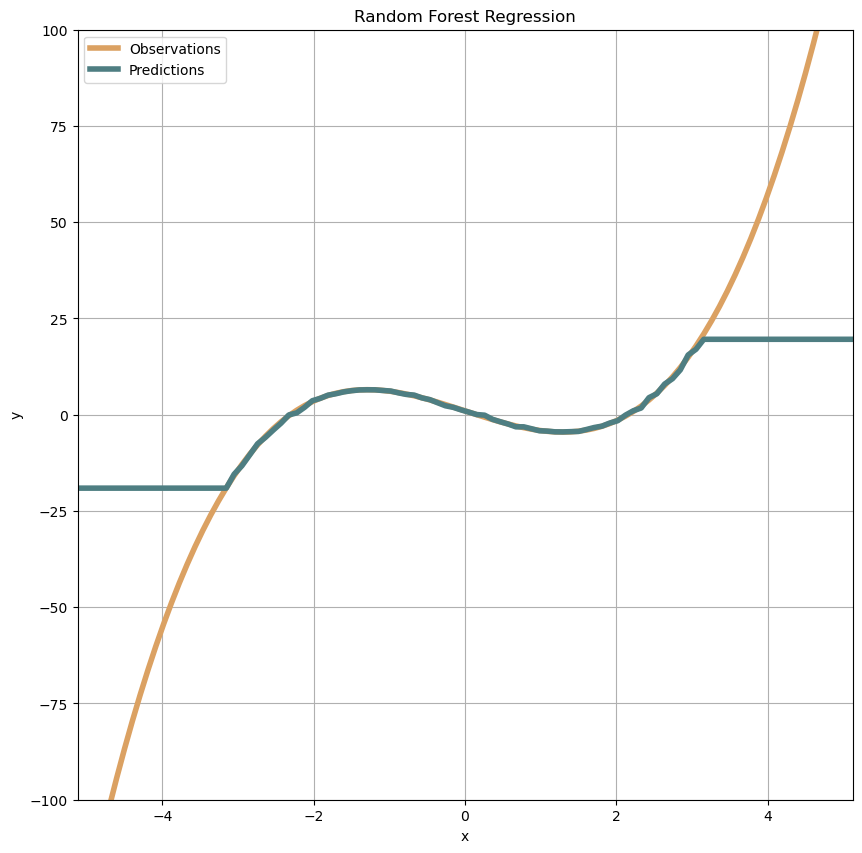

In [12]:
# Generate some test data, including observations from the true function
x_test_ext = np.linspace(-5.12, 5.12, 100)
y_obs_ext = 1.28 * x_test_ext**3 - 6.4 * x_test_ext + 1

# Instantiate and train the regressor
regressor = RandomForestRegressor(
    n_estimators= 20,
    max_depth= 20,
    oob_score=True  # Optional: enables out-of-bag scoring
)
regressor.fit(x.reshape(-1, 1), y)

# Generate predictions and calculate R^2 score
y_pred_ext = regressor.predict(x_test_ext.reshape(-1, 1))
print(r2_score(y_obs_ext, y_pred_ext))

# Plot predictions and observations
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([-5.12, 5.12])
ax.set_ylim([-100, 100])
ax.plot(x_test_ext, y_obs_ext, lw=4, color='#dba162', label='Observations')
ax.plot(x_test_ext, y_pred_ext, lw=4, color='#4e7e82', label='Predictions')
plt.legend(loc="upper left")
plt.title("Random Forest Regression")
plt.grid(True)
plt.show()